# 01 - Data Ingestion & EDA

Questa fase focalizza sul caricamento e sulla pulizia del Data Lake finanziario.

**Step:**
1. Caricamento dati locali (CSV Borsa Italiana: anagrafica + storico prezzi)
2. Data Consistency Check (ISIN comuni, overlap temporale)
3. Filtraggio universo (plain vanilla gov bonds europei)
4. Caricamento dati macro da API eterogenee (FRED, pandasdmx, eurostat)
5. Exploratory Data Analysis (EDA)

## 1.1 - Import

In [87]:
import pandas as pd
import numpy as np
import re
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1.2 - Caricamento Dati Locali (Micro-dati da SimpleToolsForInvestors)

In [88]:
# Percorsi dei file CSV locali
file_path_storico = "./dataset/Archivio con lo storico prezzi dei titoli in formato CSV(Ultimo aggiornamento 07-05-2026).csv"
file_path_anagrafica = "./dataset/Obbligazioni quotate su Borsa Italiana(Ultimo aggiornamento 07-05-2026).csv"

# Caricamento storico prezzi
df_storico = pd.read_csv(file_path_storico,
                        sep=';',
                        decimal=',',
                        parse_dates=['referencedate', 'endvaluedate'],
                        dayfirst=True)

# Caricamento anagrafica obbligazioni
try:
    df_anagrafica = pd.read_csv(file_path_anagrafica, sep=';', decimal=',')
    print(f"✓ Anagrafica caricata: {df_anagrafica.shape[0]} righe")
except Exception as e:
    print(f"✗ Errore nel caricamento dell'anagrafica: {e}")
    df_anagrafica = None

print(f"✓ Storico caricato: {df_storico.shape[0]} righe")

✓ Anagrafica caricata: 3629 righe
✓ Storico caricato: 827771 righe


In [89]:
# Pulizia base: rimozione spazi, uniformità nomi colonne
if df_anagrafica is not None:
    df_anagrafica.columns = df_anagrafica.columns.str.strip().str.lower()
    df_storico.columns = df_storico.columns.str.strip().str.lower()

# Cast di isin a stringa
if df_anagrafica is not None:
    if 'isincode' in df_anagrafica.columns:
        df_anagrafica['isincode'] = df_anagrafica['isincode'].astype(str)
    if 'isincode' in df_storico.columns:
        df_storico['isincode'] = df_storico['isincode'].astype(str)

print("\n--- Dataset Dimensions ---")
print(f"Storico prezzi: {df_storico.shape}")
if df_anagrafica is not None:
    print(f"Anagrafica: {df_anagrafica.shape}")


--- Dataset Dimensions ---
Storico prezzi: (827771, 10)
Anagrafica: (3629, 13)


In [90]:
# Preview dei dati
print("\n--- Preview Storico Prezzi ---")
display(df_storico.head())

print("\n--- Preview Anagrafica ---")
if df_anagrafica is not None:
    display(df_anagrafica.head())


--- Preview Storico Prezzi ---


,isincode,marketcode,referencedate,endvaluedate,pricetype,pricevalue,volume,mintoday,maxtoday,unnamed: 9
0,AT0000383864,MOT,2023-01-02,2023-01-03,RP,115.22,0,0.00,0.00,NaN
1,AT0000383864,MOT,2023-01-03,2023-01-04,RP,115.59,0,0.00,0.00,NaN
2,AT0000383864,MOT,2023-01-04,2023-01-05,LP,116.35,4000,116.35,116.38,NaN
3,AT0000383864,MOT,2023-01-05,2023-01-06,LP,116.50,5000,116.50,116.50,NaN
4,AT0000383864,MOT,2023-01-06,2023-01-09,LP,116.60,2000,116.60,116.60,NaN



--- Preview Anagrafica ---


,firstdate,marketcode,segmentcode,isincode,description,currencycode,minimumlot,status,issuedate,issueprice,redemptiondate,redemptionprice,unnamed: 12
0,07/05/2026,EUROTLX,EUROTLX,XS3318840223,Lottomaticag Fx 4.625% Apr32 Call Eur,EUR,100000.0,NaN,NaN,NaN,30/04/2032,NaN,NaN
1,07/05/2026,EUROTLX,EUROTLX,XS2433136194,Israel Fx 0.625% Jan32 Eur,EUR,1000.0,NaN,NaN,NaN,18/01/2032,NaN,NaN
2,07/05/2026,EUROTLX,EUROTLX,XS1936101291,Israel Fx 2.5% Jan49 Eur,EUR,1000.0,NaN,NaN,NaN,16/01/2049,NaN,NaN
3,07/05/2026,EUROTLX,EUROTLX,XS1936100483,Israel Fx 1.5% Jan29 Eur,EUR,1000.0,NaN,NaN,NaN,16/01/2029,NaN,NaN
4,07/05/2026,EUROTLX,EUROTLX,US46513JB593,Israel Fx 4.5% Apr20 Usd,USD,200000.0,NaN,NaN,NaN,03/04/2120,NaN,NaN


In [91]:
# Rimozione colonne non necessarie (segmentcode, status, unnamed)
if df_anagrafica is not None:
    cols_to_drop = [col for col in df_anagrafica.columns if 'unnamed' in col or 'status' in col or 'segmentcode' in col]
    df_anagrafica.drop(columns=cols_to_drop, inplace=True)

if df_storico is not None:
    cols_to_drop_storico = [col for col in df_storico.columns if 'unnamed' in col]
    df_storico.drop(columns=cols_to_drop_storico, inplace=True)
    
print("\n--- Preview Anagrafica ---")
if df_anagrafica is not None:
    display(df_anagrafica.head())



--- Preview Anagrafica ---


,firstdate,marketcode,isincode,description,currencycode,minimumlot,issuedate,issueprice,redemptiondate,redemptionprice
0,07/05/2026,EUROTLX,XS3318840223,Lottomaticag Fx 4.625% Apr32 Call Eur,EUR,100000.0,NaN,NaN,30/04/2032,NaN
1,07/05/2026,EUROTLX,XS2433136194,Israel Fx 0.625% Jan32 Eur,EUR,1000.0,NaN,NaN,18/01/2032,NaN
2,07/05/2026,EUROTLX,XS1936101291,Israel Fx 2.5% Jan49 Eur,EUR,1000.0,NaN,NaN,16/01/2049,NaN
3,07/05/2026,EUROTLX,XS1936100483,Israel Fx 1.5% Jan29 Eur,EUR,1000.0,NaN,NaN,16/01/2029,NaN
4,07/05/2026,EUROTLX,US46513JB593,Israel Fx 4.5% Apr20 Usd,USD,200000.0,NaN,NaN,03/04/2120,NaN


## 1.3 - Data Consistency Check (ISIN Comuni)

In [92]:
# Estraiamo gli ISIN unici sotto forma di set
isins_in_anagrafica = set(df_anagrafica['isincode'].unique())
isins_in_storico = set(df_storico['isincode'].unique())

# Analisi dell'intersezione
common_isins = isins_in_anagrafica.intersection(isins_in_storico)
only_in_anagrafica = isins_in_anagrafica - isins_in_storico
only_in_storico = isins_in_storico - isins_in_anagrafica

print("--- REPORT DATA CONSISTENCY ---")
print(f"Totale ISIN unici in Anagrafica: {len(isins_in_anagrafica)}")
print(f"Totale ISIN unici in Storico:    {len(isins_in_storico)}")
print(f"ISIN COMUNI (Utilizzabili):      {len(common_isins)}")
print(f"-----")
print(f"ISIN scartati (Solo in Anagrafica, no prezzi): {len(only_in_anagrafica)}")
print(f"ISIN scartati (Solo in Storico, no anagrafica): {len(only_in_storico)}")

--- REPORT DATA CONSISTENCY ---
Totale ISIN unici in Anagrafica: 3504
Totale ISIN unici in Storico:    1309
ISIN COMUNI (Utilizzabili):      1309
-----
ISIN scartati (Solo in Anagrafica, no prezzi): 2195
ISIN scartati (Solo in Storico, no anagrafica): 0


In [93]:
# Filtraggio: teniamo solo gli ISIN comuni
df_anagrafica_filtrato = df_anagrafica[df_anagrafica['isincode'].isin(common_isins)].copy()
df_storico_filtrato = df_storico[df_storico['isincode'].isin(common_isins)].copy()

print(f"✓ Dataset filtrato per ISIN comuni")
print(f"  Anagrafica: {df_anagrafica_filtrato.shape[0]} righe")
print(f"  Storico: {df_storico_filtrato.shape[0]} righe")

✓ Dataset filtrato per ISIN comuni
  Anagrafica: 1335 righe
  Storico: 827771 righe


## 1.4 - Filtraggio Avanzato dell'Universo di Trading

Selezioniamo solo obbligazioni governative europee **Plain Vanilla** (tasso fisso, nessuna struttura esotica).

In [94]:
print(f"ISIN totali PRIMA del filtraggio avanzato: {df_anagrafica_filtrato['isincode'].nunique()}")

# 1. Filtro per Obbligazioni Governative Europee
european_gov_codes = ['IT', 'DE', 'FR', 'ES', 'PT', 'AT', 'BE', 'NL', 'FI', 'IE', 'GR']

is_european_gov = (df_anagrafica_filtrato['isincode'].str.startswith(tuple(european_gov_codes))) & \
                  (df_anagrafica_filtrato['description'].str.contains('GOV|Btp|Schatz|OAT|Bonos|Obligaciones|Bund|BOT|CTZ|Bubill|Zc', case=False, na=False))

df_anagrafica_gov = df_anagrafica_filtrato[is_european_gov].copy()
print(f"✓ ISIN rimasti dopo filtro 'EU Government': {df_anagrafica_gov['isincode'].nunique()}")

# 2. Escludiamo Obbligazioni "Esotiche" (cedola variabile, inflation-linked, etc.)
parole_chiave_escluse = ['Futura', 'Italia', 'Inflazione', 'Indicizzato', 'Inflation', 'Valore', 'Btpi', 'Linker', 'Piu']
pattern_esclusione = '|'.join(parole_chiave_escluse)

is_exotic = df_anagrafica_gov['description'].str.contains(pattern_esclusione, case=False, na=False)
df_anagrafica_clean = df_anagrafica_gov[~is_exotic].copy()
print(f"✓ ISIN rimasti dopo esclusione 'Esotici': {df_anagrafica_clean['isincode'].nunique()}")

# Lista finale di ISIN "puri"
final_clean_isins = set(df_anagrafica_clean['isincode'].unique())

print(f"\n--- RISULTATO FINALE FILTRAGGIO ---")
print(f"Numero di obbligazioni 'Plain Vanilla' per il modello: {len(final_clean_isins)}")

# Filtrare anche lo storico con la nuova lista di ISIN puliti
df_storico_clean = df_storico_filtrato[df_storico_filtrato['isincode'].isin(final_clean_isins)].copy()
print(f"Dimensioni Storico finale: {df_storico_clean.shape}")

ISIN totali PRIMA del filtraggio avanzato: 1309
✓ ISIN rimasti dopo filtro 'EU Government': 337
✓ ISIN rimasti dopo esclusione 'Esotici': 305

--- RISULTATO FINALE FILTRAGGIO ---
Numero di obbligazioni 'Plain Vanilla' per il modello: 305
Dimensioni Storico finale: (189510, 9)


## 1.5 - Analisi della Profondità Storica

In [95]:
# Time span globale del dataset
min_date = df_storico_filtrato['referencedate'].min()
max_date = df_storico_filtrato['referencedate'].max()

print(f"--- TIME SPAN DEL DATASET STORICO ---")
print(f"Data più vecchia: {min_date.strftime('%d/%m/%Y')}")
print(f"Data più recente: {max_date.strftime('%d/%m/%Y')}")
print(f"Profondità totale: {(max_date - min_date).days} giorni")

# Quanti dati ha davvero ogni obbligazione?
history_lengths = df_storico_filtrato.groupby('isincode')['referencedate'].count()

print(f"\n--- ANALISI STORICO PER SINGOLO TITOLO ---")
print(f"Giorni di storico MEDIO per bond: {history_lengths.mean():.0f}")
print(f"Giorni di storico MEDIANO: {history_lengths.median():.0f}")
print(f"Titoli con meno di 6 mesi (< 130 giorni): {(history_lengths < 130).sum()}")
print(f"Titoli con più di 1 anno (> 250 giorni): {(history_lengths > 250).sum()}")

--- TIME SPAN DEL DATASET STORICO ---
Data più vecchia: 02/01/2023
Data più recente: 07/05/2026
Profondità totale: 1221 giorni

--- ANALISI STORICO PER SINGOLO TITOLO ---
Giorni di storico MEDIO per bond: 632
Giorni di storico MEDIANO: 833
Titoli con meno di 6 mesi (< 130 giorni): 120
Titoli con più di 1 anno (> 250 giorni): 1109


## 1.6 - Caricamento Dati Macroeconomici (API Eterogenee: FRED, Yahoo Finance)

In [138]:
import os
from dotenv import load_dotenv
load_dotenv()
import warnings
warnings.filterwarnings('ignore')
import datetime
import pandas as pd
from fredapi import Fred

# ============================================================================
# CONFIGURAZIONE FRED API KEY
# ============================================================================
# OPZIONE 1: Usa variabile d'ambiente (CONSIGLIATO - più sicuro)
# Impostala prima di eseguire il notebook:
#   Linux/Mac:  export FRED_API_KEY="tua_api_key_qui"
#   Windows:    set FRED_API_KEY=tua_api_key_qui
#   O in Python:
fred_api_key = os.environ.get('FRED_API_KEY')

# OPZIONE 2: Se non è impostata come variabile d'ambiente, inseriscila qui
if not fred_api_key:
    fred_api_key = None  # Sostituisci con "tua_api_key_qui" se necessario

if fred_api_key:
    fred = Fred(api_key=fred_api_key)
    print(f"✓ FRED API Key configurata (primi 10 caratteri: {fred_api_key[:10]}...")
else:
    fred = Fred()
    print("⚠ FRED API Key NON configurata. I dati pubblici funzioneranno comunque senza rate limits elevati.")


# Date di inizio e fine
start_date = datetime.datetime(1990, 1, 1)
end_date = datetime.datetime(2026, 5, 8)
    
# ============================================================================
# [1/3] FRED (Federal Reserve Economic Data)
# ============================================================================
print("\n[1/3] Scaricamento dati FRED...")

fred_tickers = {
    'ECB_Deposit_Rate': 'ECBDFR',              # Tasso Deposit Facility (BCE)
    'ECB_MRO_Rate': 'ECBMRRFR',                # Main Refinancing Operations Rate (BCE)
    'FED_Rate': 'EFFR',                        # Effective Federal Funds Rate (US)
    'ESI_Index': 'CSCICP02EZM460S',            # Composite Consumer Confidence for Euro Area
    'Euribor_3M': 'IR3TIB01EZM156N',           # Euribor 3M
    'Euribor_1A': 'IRLTLT01EZM156N',           # Euribor 1Y
    'VIX': 'VIXCLS'                            # Volatilità implicita S&P 500 ("paura" globale)
}

fred_series = {}
for name, ticker in fred_tickers.items():
    try:
        series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
        series.index = pd.to_datetime(series.index)
        fred_series[name] = series.rename(name)
        print(f"✓ Dato '{name}' scaricato con successo. Osservazioni: {series.notna().sum()}")
    except Exception as e:
        print(f"✗ Errore nel download di '{name}': {e}")

if fred_series:
    df_fred = pd.concat(fred_series.values(), axis=1).sort_index()
    print(f"\n✓ FRED caricato: {df_fred.shape[0]} righe x {df_fred.shape[1]} colonne")
    print(df_fred.notna().sum().to_string())
else:
    df_fred = pd.DataFrame()
    print("✗ Nessuna serie FRED scaricata correttamente.")


✓ FRED API Key configurata (primi 10 caratteri: f041051526...

[1/3] Scaricamento dati FRED...
✓ Dato 'ECB_Deposit_Rate' scaricato con successo. Osservazioni: 9990
✓ Dato 'ECB_MRO_Rate' scaricato con successo. Osservazioni: 6959
✓ Dato 'FED_Rate' scaricato con successo. Osservazioni: 6490
✓ Dato 'ESI_Index' scaricato con successo. Osservazioni: 433
✓ Dato 'Euribor_3M' scaricato con successo. Osservazioni: 385
✓ Dato 'Euribor_1A' scaricato con successo. Osservazioni: 433
✓ Dato 'VIX' scaricato con successo. Osservazioni: 9182

✓ FRED caricato: 12370 righe x 7 colonne
ECB_Deposit_Rate    9990
ECB_MRO_Rate        6959
FED_Rate            6490
ESI_Index            433
Euribor_3M           385
Euribor_1A           433
VIX                 9182


In [140]:
import yfinance as yf
# ============================================================================
# [2/3] Yahoo Finance (VSTOXX, VIX, sentiment di mercato)
# ============================================================================
print("\n[2/3] Scaricamento dati Yahoo Finance...")

yf_tickers = {
    'STOXX50': '^STOXX50E',         # Indice azioni europee
    'XEON': 'XEON.MI',              # EURO SHORT-TERM RATE
    'SEGA': 'SEGA.MI'               # iShares Core Euro Government Bond
}

df_yf: pd.DataFrame = pd.DataFrame()
for name, ticker in yf_tickers.items():
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not data.empty:
            df_yf[name] = data['Close']
            print(f"  ✓ {name} ({ticker}): OK - {len(data)} osservazioni")
    except Exception as e:
        print(f"  ✗ {name} ({ticker}): FAILED - {str(e)[:50]}")

if not df_yf.empty:
    idx = pd.to_datetime(df_yf.index, errors="coerce")
    if isinstance(idx, pd.DatetimeIndex):
        if idx.tz is not None:
            idx = idx.tz_localize(None)
        df_yf.index = idx


[2/3] Scaricamento dati Yahoo Finance...
  ✓ STOXX50 (^STOXX50E): OK - 4787 osservazioni
  ✓ XEON (XEON.MI): OK - 4656 osservazioni
  ✓ SEGA (SEGA.MI): OK - 3828 osservazioni


In [141]:
import eurostat as es
import re
from pandas.tseries.offsets import MonthEnd

# ============================================================================
# [2/3] Eurostat (HICP Headline e Core)
# ============================================================================
print("\n[2/3] Scaricamento HICP da Eurostat...")


def _normalize_eurostat_hicp(df: pd.DataFrame, series_name: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=[series_name])

    work = df.copy()
    time_cols = [col for col in work.columns if re.fullmatch(r"\d{4}-\d{2}", str(col))]
    if not time_cols:
        return pd.DataFrame(columns=[series_name])

    unit_preference = ['I15', 'I05', 'I96']
    selected_row = None
    for unit_code in unit_preference:
        candidate = work[work['unit'] == unit_code]
        if not candidate.empty:
            selected_row = candidate.iloc[0]
            break

    if selected_row is None:
        selected_row = work.iloc[0]

    series = pd.to_numeric(selected_row[time_cols], errors='coerce')
    series.index = pd.PeriodIndex(series.index.astype(str), freq='M').to_timestamp('M')
    series = series.dropna().sort_index().rename(series_name)
    return series.to_frame()

try:
    df_hicp_raw = es.get_data_df('prc_hicp_midx', filter_pars={'coicop': ['CP00'], 'geo': ['EU27_2020']})
    df_hicp_core_raw = es.get_data_df('prc_hicp_midx', filter_pars={'coicop': ['TOT_X_NRG_FOOD'], 'geo': ['EU27_2020']})

    df_hicp = _normalize_eurostat_hicp(df_hicp_raw, 'HICP_Headline')
    df_hicp_core = _normalize_eurostat_hicp(df_hicp_core_raw, 'HICP_Core')

    # Shift per allineare con i dati storici (I dati Eurostat vengono pubblicati con un mese di ritardo, quindi spostiamo indietro di 1 mese)
    df_hicp = df_hicp.shift(1)
    df_hicp_core = df_hicp_core.shift(1)

    print(f"✓ HICP Headline Eurostat: {df_hicp['HICP_Headline'].notna().sum()} osservazioni")
    print(f"✓ HICP Core Eurostat: {df_hicp_core['HICP_Core'].notna().sum()} osservazioni")

except Exception as e:
    print(f"✗ Errore nel download Eurostat HICP: {e}")
    df_hicp = pd.DataFrame()
    df_hicp_core = pd.DataFrame()


[2/3] Scaricamento HICP da Eurostat...
✓ HICP Headline Eurostat: 312 osservazioni
✓ HICP Core Eurostat: 300 osservazioni


In [142]:

# ============================================================================
# MERGE DI TUTTE LE FONTI
# ============================================================================
print("\n" + "=" * 90)
print("MERGE E PULIZIA DATI MACRO")
print("=" * 90)

# Merge esplicito di tutte le fonti disponibili
frames = []
if not df_fred.empty:
    frames.append(df_fred)
if not df_yf.empty:
    frames.append(df_yf)
if 'df_hicp' in globals() and not df_hicp.empty:
    frames.append(df_hicp)
if 'df_hicp_core' in globals() and not df_hicp_core.empty:
    frames.append(df_hicp_core)

if frames:
    df_macro = pd.concat(frames, axis=1).sort_index()
else:
    df_macro = pd.DataFrame()

# Allineamento su giorni lavorativi e forward-fill dei dati meno frequenti
if not df_macro.empty:
    business_index = pd.bdate_range(start=df_macro.index.min(), end=end_date)
    df_macro = df_macro.reindex(business_index).ffill()

# Assicuriamoci che la colonna delle date sia in formato datetime e ordinata
if not df_macro.empty:
    df_macro.index = pd.to_datetime(df_macro.index)
    df_macro.sort_index(inplace=True)

print(f"\n✓ Dataset macro-economico COMPLETO:")
print(f"  Shape: {df_macro.shape}")
print(f"  Colonne: {list(df_macro.columns)}")
print(f"  Time range: {df_macro.index.min().date()} to {df_macro.index.max().date()}")
print(f"  Missing values totali: {df_macro.isna().sum().sum()}")
print("\nMissing per colonna:")
print(df_macro.isna().sum().sort_values(ascending=False).to_string())



MERGE E PULIZIA DATI MACRO

✓ Dataset macro-economico COMPLETO:
  Shape: (9485, 12)
  Colonne: ['ECB_Deposit_Rate', 'ECB_MRO_Rate', 'FED_Rate', 'ESI_Index', 'Euribor_3M', 'Euribor_1A', 'VIX', 'STOXX50', 'XEON', 'SEGA', 'HICP_Headline', 'HICP_Core']
  Time range: 1990-01-01 to 2026-05-08
  Missing values totali: 28454

Missing per colonna:
SEGA                5230
XEON                4698
STOXX50             4499
HICP_Core           2892
FED_Rate            2740
HICP_Headline       2630
ECB_Deposit_Rate    2349
ECB_MRO_Rate        2349
Euribor_3M          1066
VIX                    1
ESI_Index              0
Euribor_1A             0


## 1.7 - EDA (Exploratory Data Analysis)

In [143]:
# Statistiche descrittive dell'anagrafica
print("--- STATISTICHE ANAGRAFICA BOND ---")
display(df_anagrafica_clean[['isincode', 'description']].describe())


--- STATISTICHE ANAGRAFICA BOND ---


,isincode,description
count,305,305
unique,305,305
top,IT0005707614,Btp Fx 3.15% Jun31 Eur
freq,1,1


--- STATISTICHE PREZZI ---
count    189510.000000
mean         93.278877
std          15.306737
min          24.160000
25%          86.950000
50%          96.060000
75%         101.470000
max         138.490000
Name: pricevalue, dtype: float64


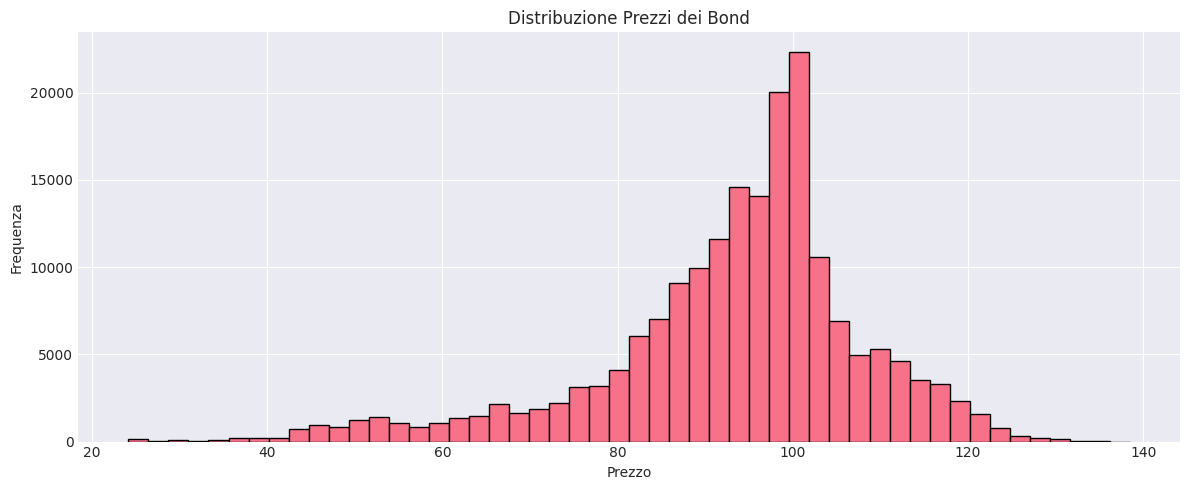

In [144]:
# Analisi dei prezzi
print("--- STATISTICHE PREZZI ---")
print(df_storico_clean['pricevalue'].describe())

# Distribuzione prezzi
fig, ax = plt.subplots(figsize=(12, 5))
df_storico_clean['pricevalue'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribuzione Prezzi dei Bond')
ax.set_xlabel('Prezzo')
ax.set_ylabel('Frequenza')
plt.tight_layout()
plt.show()

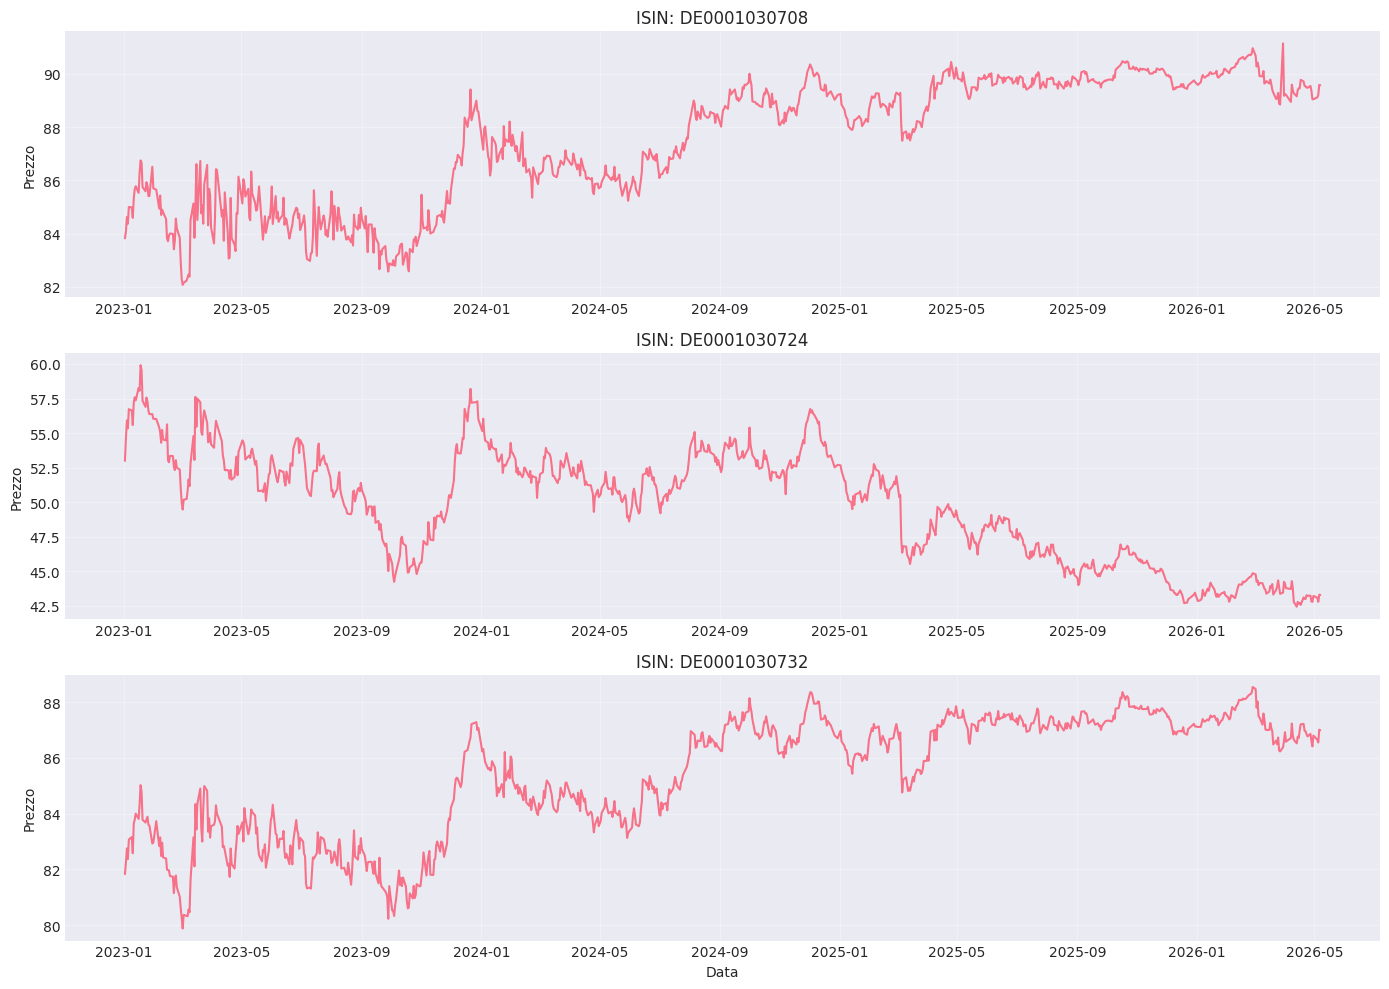

In [135]:
# Time series dei prezzi per un campione di bond
sample_isins = df_storico_clean['isincode'].unique()[:3]
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, isin in enumerate(sample_isins):
    data = df_storico_clean[df_storico_clean['isincode'] == isin].sort_values('referencedate')
    axes[idx].plot(data['referencedate'], data['pricevalue'], linewidth=1.5)
    axes[idx].set_title(f'ISIN: {isin}')
    axes[idx].set_ylabel('Prezzo')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Data')
plt.tight_layout()
plt.show()

--- STATISTICHE DATI MACRO COMPLETI ---


,ECB_Deposit_Rate,ECB_MRO_Rate,FED_Rate,ESI_Index,Euribor_3M,Euribor_1A,VIX,STOXX50,XEON,SEGA,HICP_Headline,HICP_Core
count,7136.000000,7136.000000,6745.000000,9485.000000,8419.000000,9485.000000,9484.000000,4986.000000,4787.000000,4255.000000,6855.000000,6593.000000
mean,1.085377,2.092727,1.954076,-9.988202,2.244134,4.329164,19.439086,3523.211112,138.773344,106.815148,98.015912,98.827332
std,1.422564,1.835241,1.969246,5.242640,2.126174,2.797707,7.735217,868.201033,3.063409,10.820407,16.082320,11.873257
min,-0.500000,0.000000,0.040000,-27.500000,-0.581957,-0.091882,9.140000,1809.979980,132.399994,85.015778,71.600000,79.200000
25%,-0.200000,0.050000,0.140000,-13.200000,0.192000,2.813801,13.940000,2908.215088,136.920250,97.793709,85.580000,89.640000
50%,1.000000,2.000000,1.260000,-10.100000,2.137238,4.040693,17.610000,3386.674927,138.481293,108.556549,98.850000,98.440000
75%,2.250000,4.250000,3.750000,-5.900000,3.922381,5.304357,22.730000,4060.602600,139.753006,112.888470,105.420000,104.730000
max,4.000000,4.500000,7.030000,-0.500000,7.580000,11.079040,82.690000,6173.319824,149.058899,127.180946,133.630000,126.310000


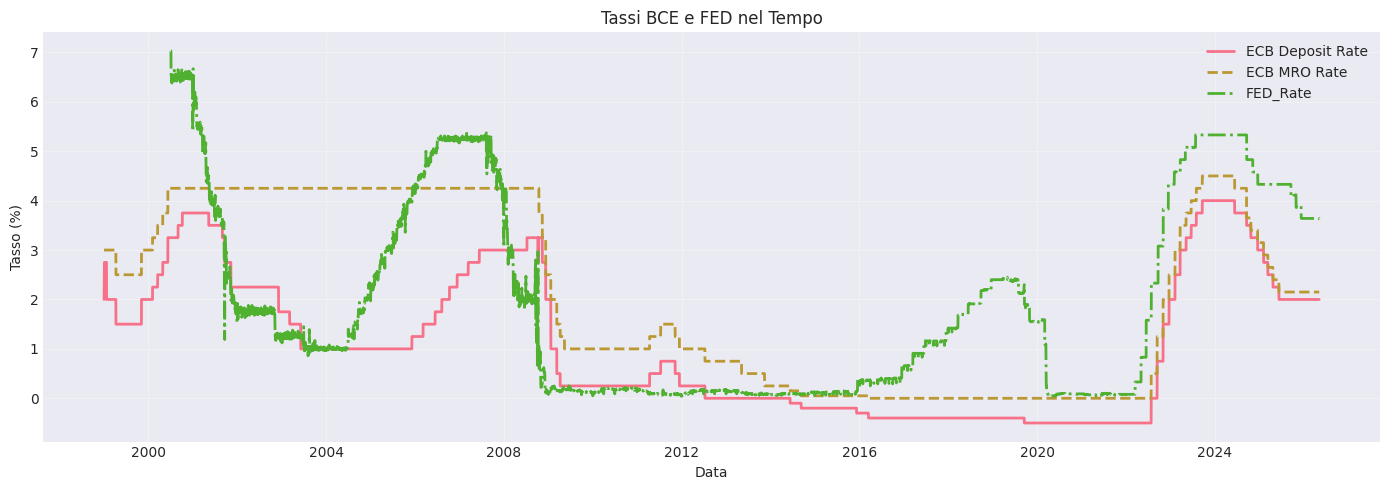

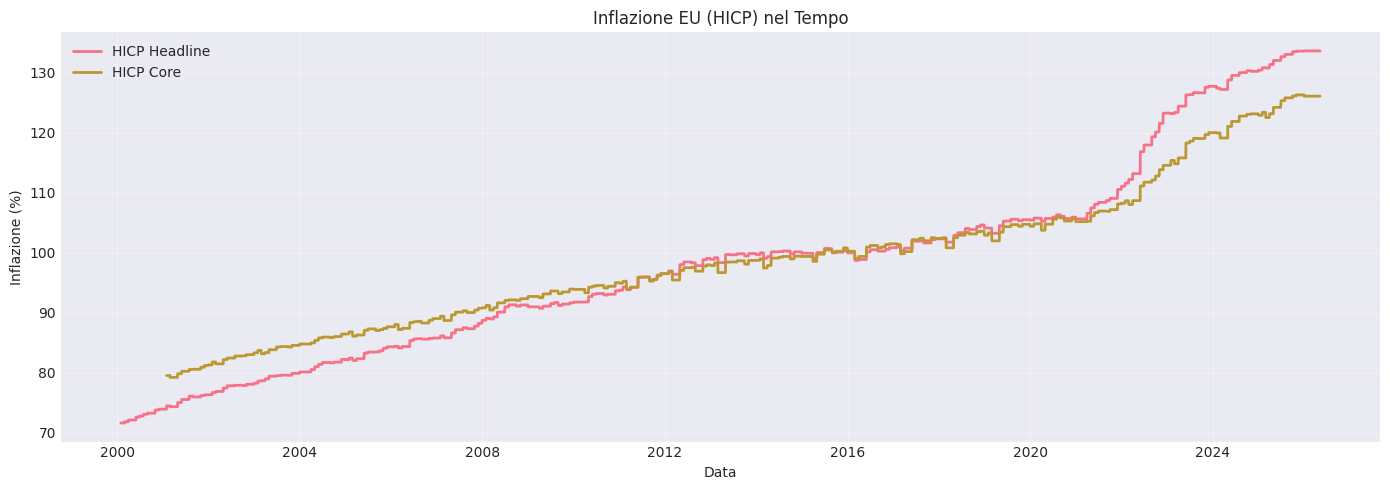

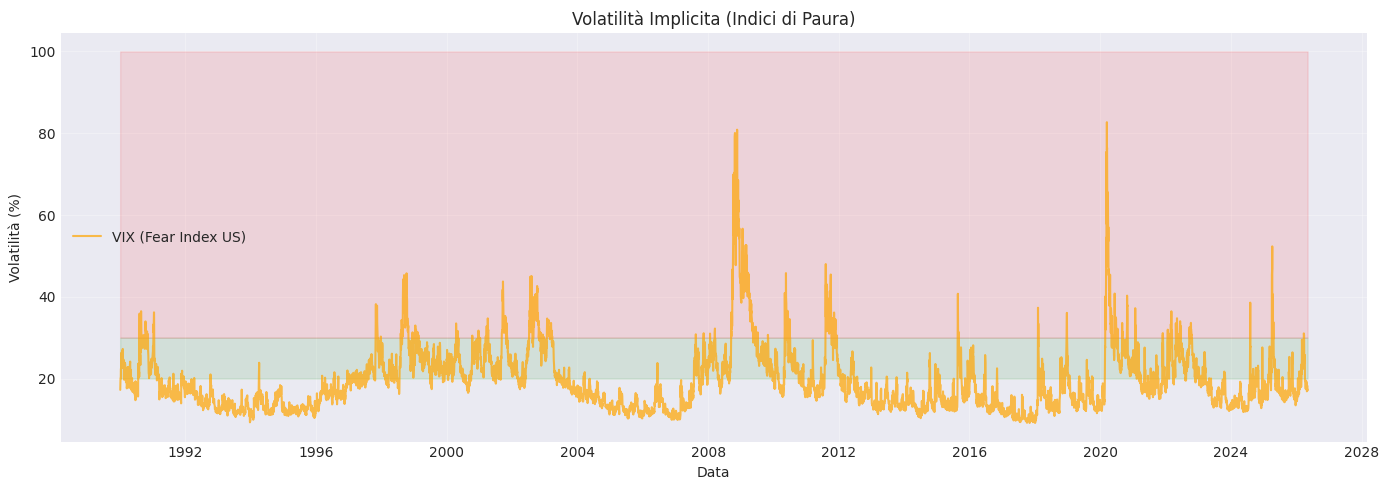

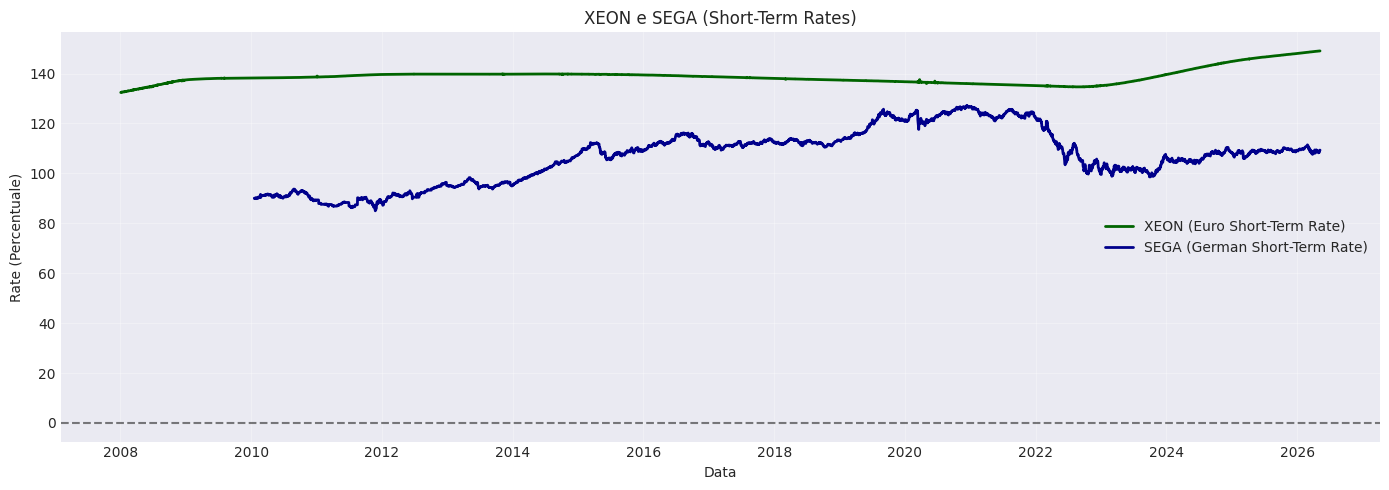

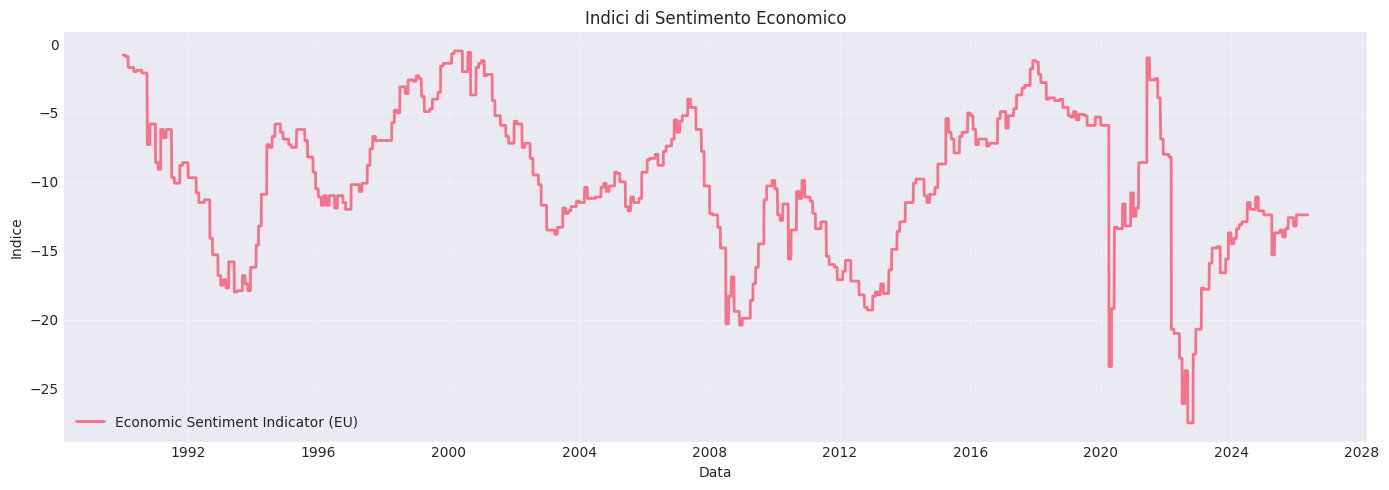

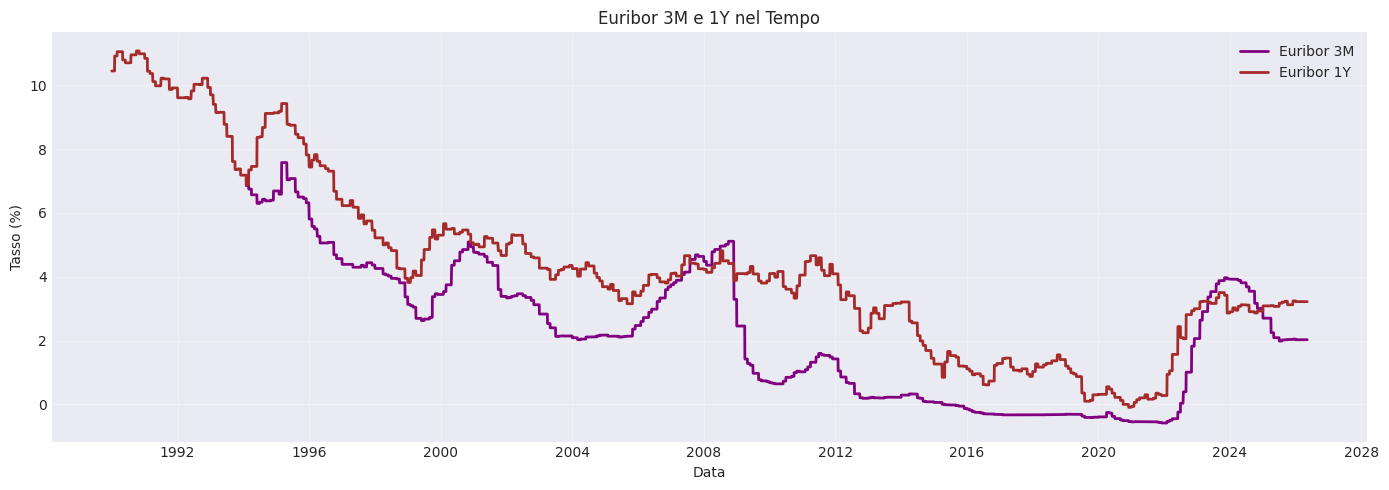

In [148]:
# Analisi dati macro
print("--- STATISTICHE DATI MACRO COMPLETI ---")
display(df_macro.describe())

# 1. Tassi BCE e FED nel tempo
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_macro.index, df_macro['ECB_Deposit_Rate'], label='ECB Deposit Rate', linewidth=2)
if 'ECB_MRO_Rate' in df_macro.columns:
    ax.plot(df_macro.index, df_macro['ECB_MRO_Rate'], label='ECB MRO Rate', linewidth=2, linestyle='--')
if 'FED_Rate' in df_macro.columns:
    ax.plot(df_macro.index, df_macro['FED_Rate'], label='FED_Rate', linewidth=2, linestyle='-.')
ax.set_title('Tassi BCE e FED nel Tempo')
ax.set_ylabel('Tasso (%)')
ax.set_xlabel('Data')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Inflazione (HICP Headline vs Core)
if 'HICP_Headline' in df_macro.columns or 'HICP_Core' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'HICP_Headline' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['HICP_Headline'], label='HICP Headline', linewidth=2)
    if 'HICP_Core' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['HICP_Core'], label='HICP Core', linewidth=2)
    ax.set_title('Inflazione EU (HICP) nel Tempo')
    ax.set_ylabel('Inflazione (%)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. Volatilità di mercato (VIX)
if 'VIX' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'VIX' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['VIX'], label='VIX (Fear Index US)', linewidth=1.5, color='orange', alpha=0.7)
    ax.set_title('Volatilità Implicita (Indici di Paura)')
    ax.set_ylabel('Volatilità (%)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.fill_between(df_macro.index, 20, 30, alpha=0.1, color='green', label='Normal')
    ax.fill_between(df_macro.index, 30, 100, alpha=0.1, color='red', label='High Fear')
    plt.tight_layout()
    plt.show()

# 4. XEON e SEGA 
if 'XEON' in df_macro.columns or 'SEGA' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'XEON' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['XEON'], label='XEON (Euro Short-Term Rate)', linewidth=2, color='darkgreen')
    if 'SEGA' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['SEGA'], label='SEGA (German Short-Term Rate)', linewidth=2, color='darkblue')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_title('XEON e SEGA (Short-Term Rates)')
    ax.set_ylabel('Rate (Percentuale)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5. Indice di sentimento economico (ESI)
if 'ESI_Index' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'ESI_Index' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['ESI_Index'], label='Economic Sentiment Indicator (EU)', linewidth=2)
    ax.set_title('Indici di Sentimento Economico')
    ax.set_ylabel('Indice')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6. Euribor 3M e 1Y
if 'Euribor_3M' in df_macro.columns or 'Euribor_1A' in df_macro.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'Euribor_3M' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['Euribor_3M'], label='Euribor 3M', linewidth=2, color='purple')
    if 'Euribor_1A' in df_macro.columns:
        ax.plot(df_macro.index, df_macro['Euribor_1A'], label='Euribor 1Y', linewidth=2, color='brown')
    ax.set_title('Euribor 3M e 1Y nel Tempo')
    ax.set_ylabel('Tasso (%)')
    ax.set_xlabel('Data')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1.8 - Save Cleaned Data for Next Stages

In [146]:
# Salva i dataset puliti per il prossimo notebook
df_anagrafica_clean.to_csv('./data/df_anagrafica_clean.csv', index=False)
df_storico_clean.to_csv('./data/df_storico_clean.csv', index=False)
df_macro.to_csv('./data/df_macro.csv')

print("✓ Dataset puliti salvati in ./data/")

✓ Dataset puliti salvati in ./data/
